# SW Plots

In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import pandas as pd
import os

In [2]:
## Read in IRWin Station Data
from pathlib import Path, PurePath
SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')

PD_OPTS = dict(
    parse_dates=True,
    index_col=0,
    names=['Temp', 'VIS_IN', 'NIR_IN', 'VIS_OUT', 'NIR_OUT'],
    header=0,
)

irwin_pyra = pd.concat([
    # pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv', **PD_OPTS),
])

irwin_pyra = irwin_pyra.fillna({'VIS_IN': 0}).astype(np.float64)

In [3]:
# MODELED
save_dir = 'modeled-station-data'
save_dirs3 = 's3-new'
save_dirm1 = 'm1-dir-dif'

s3_dsw3 = xr.open_dataset(os.path.join(save_dirs3, 's3_dsw3_22.nc'))
s3_dsw1 = xr.open_dataset(os.path.join(save_dirs3, 's3_dsw1_22.nc'))
s3_dsw30 = xr.open_dataset(os.path.join(save_dirs3, 's3_dsw30_22.nc'))
s3_k = xr.open_dataset(os.path.join(save_dirs3, 's3_k_22.nc'))
s3_ghi = xr.open_dataset(os.path.join(save_dirs3, 's3_ghi_22.nc'))

m1_dsw3 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw3.nc'))
m1_dsw1 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw1.nc'))
m1_dsw30 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw30.nc'))
m1_k = xr.open_dataset(os.path.join(save_dir, 'm1_k.nc'))
m1_ghi = xr.open_dataset(os.path.join(save_dir, 'm1_ghi.nc'))
m1_dir22 = xr.open_dataset(os.path.join(save_dirm1, 'm1_dir_22.nc'))
m1_dif22 = xr.open_dataset(os.path.join(save_dirm1, 'm1_dif_22.nc'))

irwin_dsw3 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw3.nc'))
irwin_dsw30 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw30.nc'))
irwin_dsw1 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw1.nc'))
irwin_k = xr.open_dataset(os.path.join(save_dir, 'irwin_k.nc'))
irwin_ghi = xr.open_dataset(os.path.join(save_dir, 'irwin_ghi.nc'))

sos_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw3.nc'))
sos_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw1.nc'))
sos_dsw30 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw30.nc'))
sos_k = xr.open_dataset(os.path.join(save_dir, 'sos_k.nc'))
sos_ghi = xr.open_dataset(os.path.join(save_dir, 'sos_ghi.nc'))

In [4]:
# STATION DATA
save_dir = 'station-data'

# SAIL M1 QCRAD LONG
subset_sw_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_sw.nc'))
subset_dif_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_diff.nc'))
subset_dir_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dir.nc'))
subset_best_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_best_sw.nc'))
subset_zenith_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_zen.nc'))
sub_dirh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dirh.nc'))
sub_difh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_difh_xx.nc'))
sub_dirh_hourly = sub_dirh_hourly['__xarray_dataarray_variable__'].rename('short_direct_normal').to_dataset()

# SAIL M1 & S3
m1_sw_hourly_sail = xr.open_dataset(os.path.join(save_dir, 'm1_sw.nc'))
s3_sw_hourly_sail = xr.open_dataset(os.path.join(save_dir, 's3_sw.nc'))

# SOS
sos_path = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/sos-isfs/hourlyAvg_radiation_uw.nc'
ds = xr.open_dataset(sos_path)

In [5]:
start_wy2022 = '2021-12-01 00:00'
end_wy2022   = '2022-05-01 23:00'
win = 24  # 24-hour rolling window

# SAIL S3 Station
s3_obs_hourly = s3_sw_hourly_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
s3_obs_smoothed = s3_obs_hourly.rolling(time=win, center=True).mean()
# S3 Modeled
s3_model_smoothed = s3_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
s3_k_smoothed = s3_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()

# SAIL M1 Station
m1_obs_hourly0 = m1_sw_hourly_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022))
m1_obs_smoothed = m1_obs_hourly0.rolling(time=win, center=True).mean()
# M1 QCRAD
m1_obs_hourly = subset_best_hourly['BestEstimate_down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022))
m1qc_obs_smoothed = m1_obs_hourly.rolling(time=win, center=True).mean()
dir_obs = subset_dir_hourly['short_direct_normal'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dirh_obs = sub_dirh_hourly['short_direct_normal'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dif_obs = subset_dif_hourly['down_short_diffuse_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dir_obs_smoothed = dir_obs.rolling(time=win, center=True).mean()
dirh_obs_smoothed = dirh_obs.rolling(time=win, center=True).mean()
dif_obs_smoothed = dif_obs.rolling(time=win, center=True).mean()
# M1 Modeled
m1_model_smoothed = m1_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
m1_k_smoothed = m1_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()
dirh_model = m1_dir22['dir'] * np.cos(np.deg2rad(subset_zenith_hourly.clip(min=0, max=90))).clip(min=0, max=1)
dirh_model = dirh_model['zenith'].rename('dsw3h').to_dataset().sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dirh_model_smoothed = dirh_model.rolling(time=win, center=True).mean()
dif_model = m1_dif22['dif'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dif_model = dif_model.rename('dsw3h').to_dataset()


dif_model_smoothed = dif_model.rolling(time=win, center=True).mean()

# ======= Irwin Station (Pandas-based) =======
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_hourly.index = pd.to_datetime(irwin_pyra_hourly.index)
irwin_obs_hourly = irwin_pyra_hourly.loc[start_wy2022:end_wy2022]
irwin_obs_smoothed = irwin_obs_hourly['VIS_IN'].rolling(window=win, center=True).mean()
# irwin_obs = irwin_obs.where(irwin_obs > 0)
# Irwin Modeled
irwin_model_smoothed = irwin_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
irwin_k_smoothed = irwin_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()



## Calculate bias df

In [6]:

# Define time range
start = np.datetime64('2021-12-01')
end = np.datetime64('2022-05-01')
k_thresh = 0.6

def compute_bias_and_category2(obs_da, model_ds, k_ds, station_name, start, end, k_thresh):
    # Slice and convert to pandas Series
    obs = obs_da.sel(time=slice(start, end)).to_series()
    model = model_ds['dsw3h'].sel(time=slice(start, end)).to_series()
    k = k_ds['k'].sel(time=slice(start, end)).to_series()

    # Filter invalid values (<= 0 or > 1000)
    obs = obs.where((obs > 0) & (obs <= 1100))
    model = model.where((model > 0) & (model <= 1100))
    k = k.where((k >= 0) & (k <= 1))

    # Combine and align all time series
    df = pd.concat([obs, model, k], axis=1, keys=['obs', 'model', 'k']).dropna()

    # Compute bias and category
    df['bias'] = df['model'] - df['obs']
    df['category'] = np.where(df['k'] < k_thresh, 'Clear', 'Cloudy')
    df['station'] = station_name

    return df[['station', 'bias', 'category']]


# S3 and M1 from xarray
s3_df = compute_bias_and_category2(s3_obs_hourly, s3_dsw3, s3_k, 'SAIL S3', start, end, k_thresh)
m1_df = compute_bias_and_category2(m1_obs_hourly, m1_dsw3, m1_k, 'SAIL M1 QCRAD', start, end, k_thresh)

# Irwin from pandas
irwin_obs_clipped = irwin_obs_hourly['VIS_IN'].loc[start:end].copy()
irwin_obs_clipped[irwin_obs_clipped <= 0] = np.nan  # Set zero or negative to NaN

irwin_df = pd.DataFrame({
    'obs': irwin_obs_clipped,
    'model': irwin_dsw3['dsw3h'].sel(time=slice(start, end)).to_series(),
    'k': irwin_k['k'].sel(time=slice(start, end)).to_series()
}).dropna()

irwin_df = irwin_df.where(irwin_df['model'] > 0).dropna()

irwin_df['bias'] = irwin_df['model'] - irwin_df['obs']
irwin_df['category'] = np.where(irwin_df['k'] < k_thresh, 'Clear', 'Cloudy')
irwin_df['station'] = 'Irwin Study Plot'
irwin_df = irwin_df[['station', 'bias', 'category']]

# Combine all
combined_df = pd.concat([s3_df, m1_df, irwin_df])



In [7]:
print(m1_df.max())
print(s3_df.max())
print(irwin_df.max())

station     SAIL M1 QCRAD
bias           652.048157
category           Cloudy
dtype: object
station        SAIL S3
bias        681.827942
category        Cloudy
dtype: object
station     Irwin Study Plot
bias              627.554222
category              Cloudy
dtype: object


In [8]:

def limit_2_98(df):
    # Calculate the 2nd and 98th percentiles
    lower_percentile = df['bias'].quantile(0.02)
    upper_percentile = df['bias'].quantile(0.98)
    
    # Filter the DataFrame to keep values within the range
    df_filtered = df[(df['bias'] >= lower_percentile) & (df['bias'] <= upper_percentile)]
    
    return(df_filtered)



m1_df2 = limit_2_98(m1_df)
s3_df2 = limit_2_98(s3_df)
irwin_df2 = limit_2_98(irwin_df)

In [9]:
print("SW Bias (Modeled - Station)")
print("\nSAIL M1 QCRAD:")
print(m1_df2.groupby('category')['bias'].agg(['min', 'mean', 'max']))
print("SAIL S3:")
print(s3_df2.groupby('category')['bias'].agg(['min', 'mean', 'max']))
print("\nIrwin Study Plot:")
print(irwin_df2.groupby('category')['bias'].agg(['min', 'mean', 'max']))

SW Bias (Modeled - Station)

SAIL M1 QCRAD:
                 min       mean         max
category                                   
Clear    -156.959351  28.133724  386.914795
Cloudy   -160.993561  72.866226  391.854004
SAIL S3:
                min        mean         max
category                                   
Clear    -41.217987   98.868103  418.961243
Cloudy   -59.473450  101.504013  418.516113

Irwin Study Plot:
                 min       mean         max
category                                   
Clear    -196.536033  31.792913  438.685660
Cloudy   -199.009809  61.387298  429.616288


# Figure 1

/scratch/local/u1037042/5104480/ipykernel_3395269/122915188.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_df2, x='category', y='bias',
/scratch/local/u1037042/5104480/ipykernel_3395269/122915188.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=s3_df2, x='category', y='bias',
/scratch/local/u1037042/5104480/ipykernel_3395269/122915188.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=irwin_df2, x='category', y='bias',


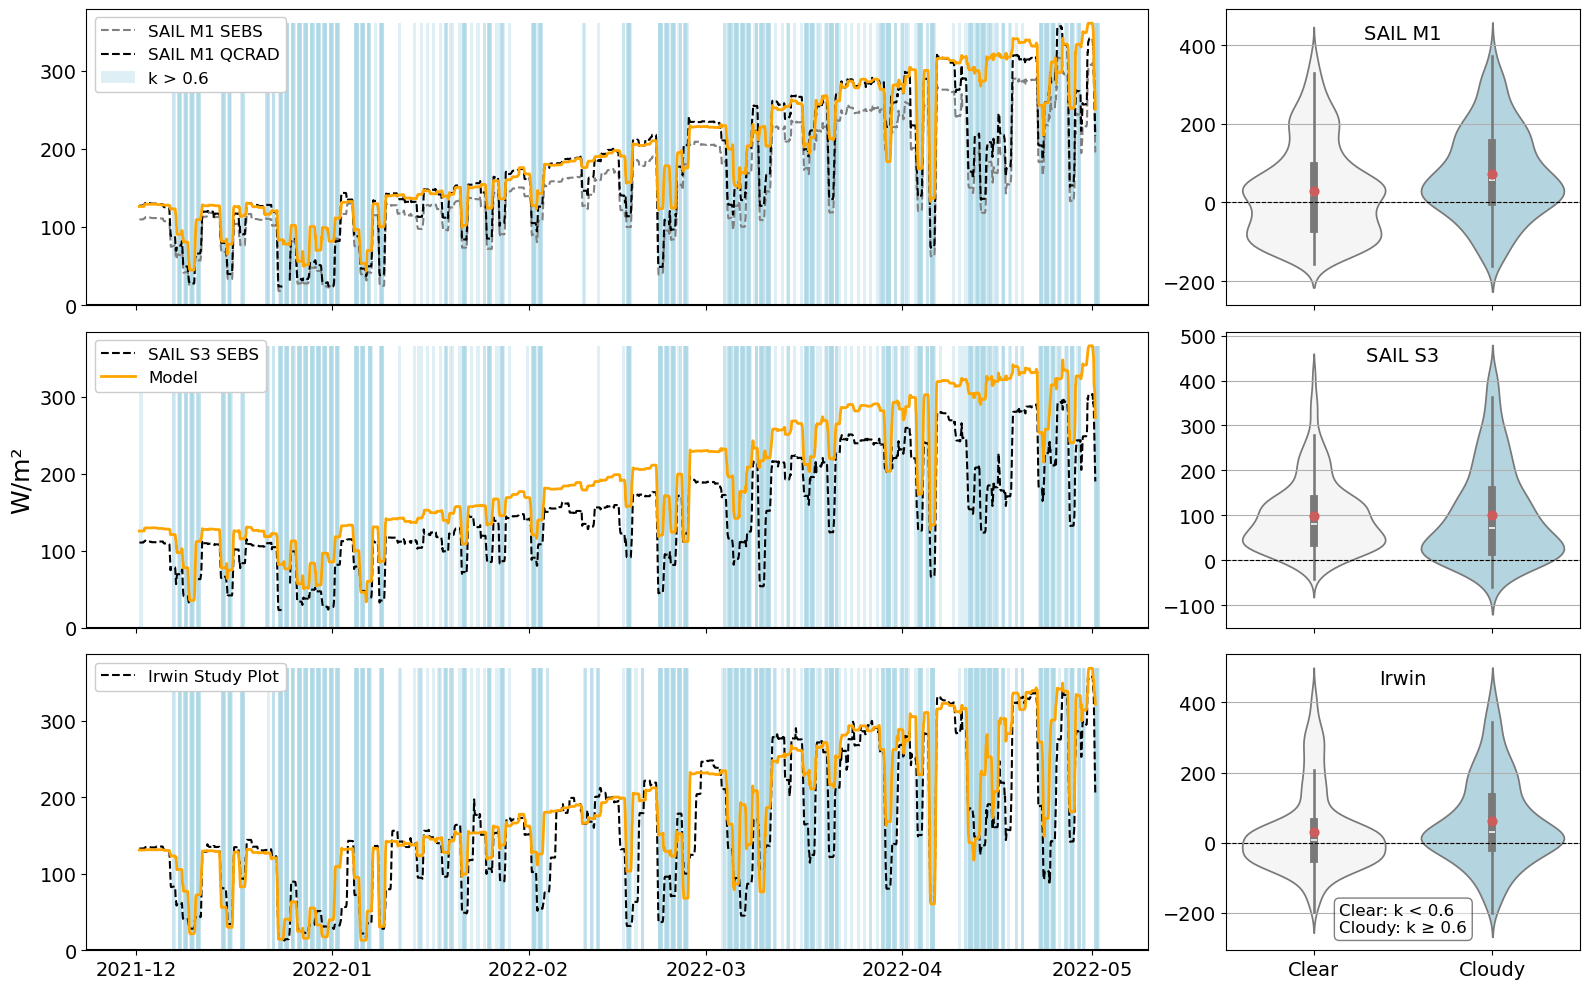

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(16, 10),
    sharex='col', #sharey='row',
    gridspec_kw={'width_ratios': [3, 1]}
)

# Font sizes
tick_size = 14
legend_size = 12
label_size = 18
lwd = 2
# k_thresh = 0.8

# ==== Row 1: M1 ====
axes[0, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * m1_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4, label='k > 0.6')
axes[0, 0].plot(m1_obs_smoothed['time'], m1_obs_smoothed, linestyle='--', color='grey', label='SAIL M1 SEBS')
axes[0, 0].plot(m1qc_obs_smoothed['time'], m1qc_obs_smoothed, linestyle='--', color='black', label='SAIL M1 QCRAD')
axes[0, 0].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[0, 0].axhline(0, color='black')
axes[0, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[0, 0].set_ylabel('W/m²', fontsize=label_size)
axes[0, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=m1_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[0, 1])

axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].grid(True, axis='y')
# axes[0, 1].legend().remove()
axes[0, 1].tick_params(labelsize=tick_size)
axes[0, 1].text(0.5, 0.95, 'SAIL M1', transform=axes[0,1].transAxes,
             fontsize=14, va='top', ha='center')

m1_means = m1_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[0, 1].scatter(i, m1_means[cat], color='indianred', zorder=5, s=40)




# ==== Row 0: S3 ====
# -- Time Series --
axes[1, 0].bar(s3_k_smoothed['time'], (s3_k_smoothed['k'] > k_thresh) * s3_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4)
axes[1, 0].plot(s3_obs_smoothed['time'], s3_obs_smoothed, color='black', linestyle='--', label='SAIL S3 SEBS')
axes[1, 0].plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='Model')
axes[1, 0].axhline(0, color='black')
axes[1, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[1, 0].set_ylabel('W/m²', fontsize=label_size)
axes[1, 0].tick_params(labelsize=tick_size)

# -- Violin Plot --
sns.violinplot(data=s3_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[1, 1])
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")
axes[1, 1].grid(True, axis='y')
# axes[1, 1].legend().remove()
axes[1, 1].tick_params(labelsize=tick_size)
axes[1, 1].text(0.5, 0.95, 'SAIL S3', transform=axes[1,1].transAxes,
             fontsize=14, va='top', ha='center')

# Add mean bias dot
s3_means = s3_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[1, 1].scatter(i, s3_means[cat], color='indianred', zorder=5, s=40)



# ==== Row 2: Irwin ====
axes[2, 0].bar(irwin_k_smoothed['time'], (irwin_k_smoothed['k'] > k_thresh) * irwin_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4)
axes[2, 0].plot(irwin_obs_smoothed.index, irwin_obs_smoothed, linestyle='--', color='black', label='Irwin Study Plot')
axes[2, 0].plot(irwin_model_smoothed['time'], irwin_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[2, 0].axhline(0, color='black')
axes[2, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[2, 0].set_ylabel('W/m²', fontsize=label_size)
axes[2, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=irwin_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[2, 1])

axes[2, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2, 1].set_ylabel("")
axes[2, 1].set_xlabel("")
axes[2, 1].grid(True, axis='y')
# axes[2, 1].legend().remove()
axes[2, 1].tick_params(labelsize=tick_size)
axes[2, 1].text(0.5, 0.95, 'Irwin', transform=axes[2,1].transAxes,
             fontsize=14, va='top', ha='center')

irwin_means = irwin_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[2, 1].scatter(i, irwin_means[cat], color='indianred', zorder=5, s=40)

# Text and box properties
textstr = "Clear: k < 0.6\nCloudy: k ≥ 0.6"
props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='black')

# Place it in bottom-left
axes[2, 1].text(
    0.32, 0.05, textstr,
    # transform=ax.transAxes,
    transform=axes[2,1].transAxes,
    fontsize=12,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=props
)

# Final layout
plt.tight_layout()
plt.show()

# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-figs-july-2025/"
# plt.savefig(svpth + 'fig01-wy22-sw-k-bias.png', dpi=300, bbox_inches='tight')

# Figure 2

In [11]:
# Create bias df

# S3 and M1 from xarray
# m1_df = compute_bias_and_category2(m1_obs_hourly, m1_dsw3, m1_k, 'SAIL M1 QCRAD', start, end, k_thresh)
m1_dir = compute_bias_and_category2(dirh_obs, dirh_model, m1_k, 'SAIL M1 DIR', start, end, k_thresh)
m1_dif = compute_bias_and_category2(dif_obs, dif_model, m1_k, 'SAIL M1 DIF', start, end, k_thresh)


# m1_df2 = limit_2_98(m1_df)
m1_dir2 = limit_2_98(m1_dir)
m1_dif2 = limit_2_98(m1_dif)

In [12]:
print("SW Bias by Component (Modeled - Station)")
print("\nSAIL M1 QCRAD:")
print(m1_df2.groupby('category')['bias'].agg(['min', 'mean', 'max']))
print("\nM1 Direct:")
print(m1_dir2.groupby('category')['bias'].agg(['min', 'mean', 'max']))
print("\nM1 Diffuse:")
print(m1_dif2.groupby('category')['bias'].agg(['min', 'mean', 'max']))

SW Bias by Component (Modeled - Station)

SAIL M1 QCRAD:
                 min       mean         max
category                                   
Clear    -156.959351  28.133724  386.914795
Cloudy   -160.993561  72.866226  391.854004

M1 Direct:
                 min       mean         max
category                                   
Clear    -259.551025  64.542244  556.845825
Cloudy   -283.315491   7.486167  264.257843

M1 Diffuse:
                 min       mean         max
category                                   
Clear    -285.779297 -24.898571  262.317017
Cloudy   -204.311798  77.727341  314.031677


/scratch/local/u1037042/5104480/ipykernel_3395269/386884186.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_df2, x='category', y='bias',
/scratch/local/u1037042/5104480/ipykernel_3395269/386884186.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_dir2, x='category', y='bias',
/scratch/local/u1037042/5104480/ipykernel_3395269/386884186.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_dif2, x='category', y='bias',


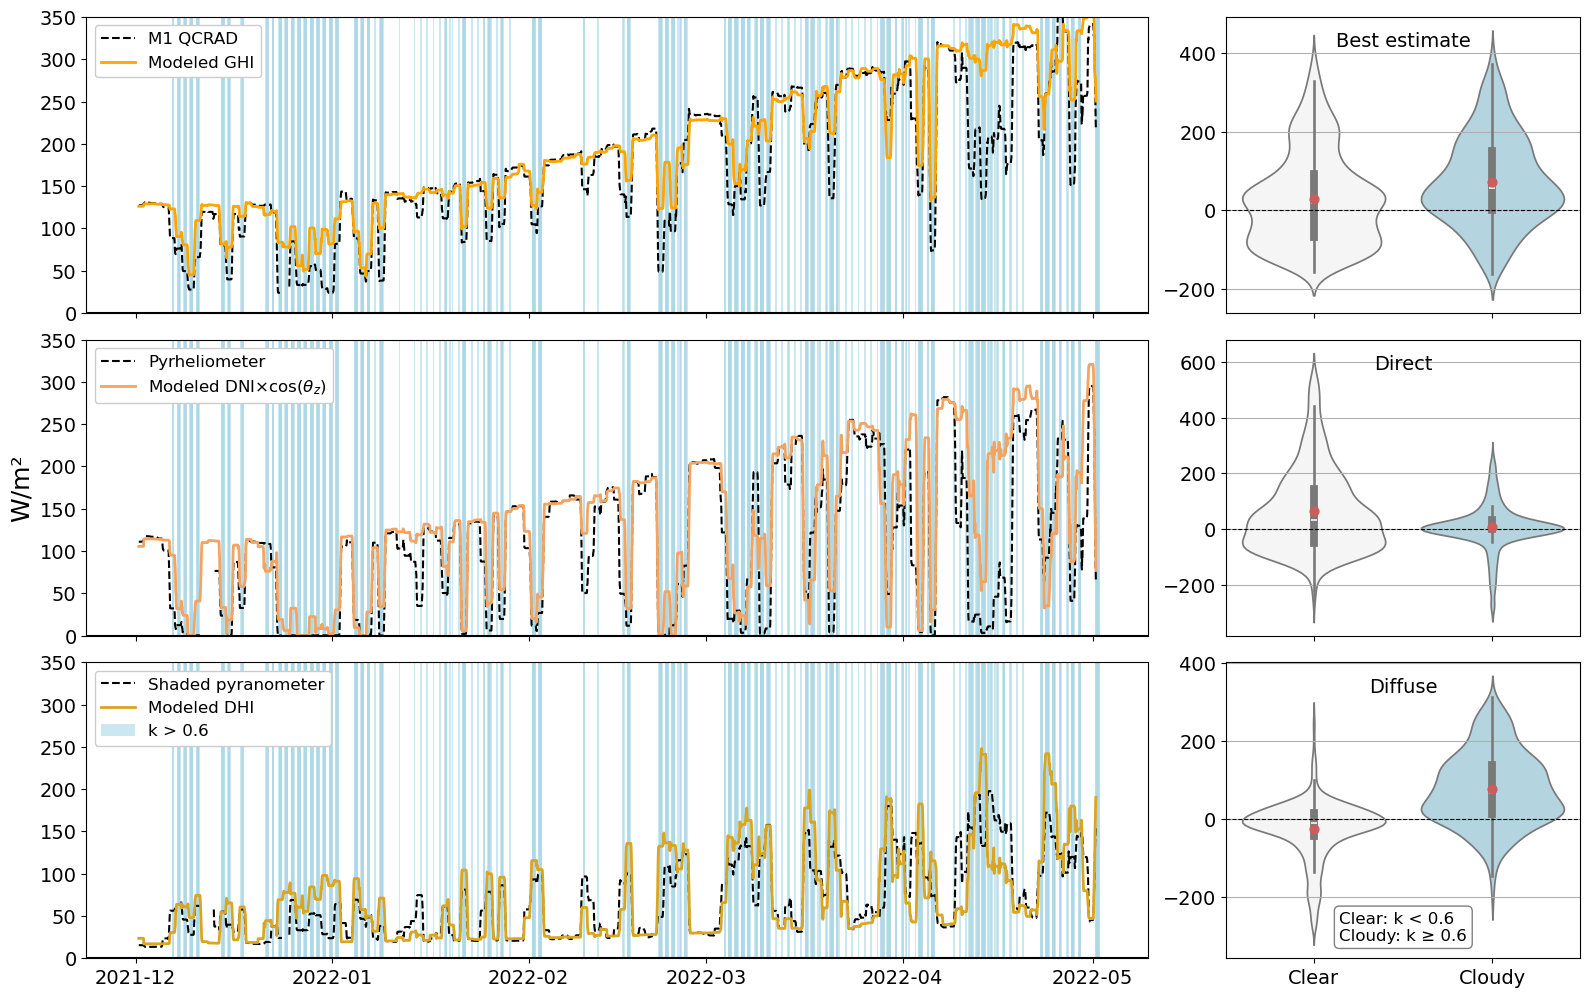

In [27]:
# PLOT FIGURE 2

fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(16, 10),
    sharex='col',
    gridspec_kw={'width_ratios': [3, 1]}
)

tick_size = 14
legend_size = 12
label_size = 18
lwd = 2
k_thresh = 0.6


# ===== Row 1: Best =====
axes[0, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * 380, #m1_model_smoothed['dsw3h'].max(), #350, #m1_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.3, alpha=0.6)
axes[0, 0].plot(m1qc_obs_smoothed['time'], m1qc_obs_smoothed, linestyle='--', color='black', label='M1 QCRAD')
axes[0, 0].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='Modeled GHI')
axes[0, 0].axhline(0, color='black')
axes[0, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[0, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=m1_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[0, 1])
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].text(0.5, 0.95, 'Best estimate', transform=axes[0, 1].transAxes,
                fontsize=14, va='top', ha='center')
axes[0, 1].tick_params(labelsize=tick_size)
axes[0, 1].grid(True, axis='y')
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")

best_means = m1_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[0, 1].scatter(i, best_means[cat], color='indianred', zorder=5, s=40)



# ===== Row 2: Direct =====
axes[1, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * 380, #m1_model_smoothed['dsw3h'].max(), #350, #dir_model_smoothed.max(),
               color='lightblue', width=0.3, alpha=0.6)

axes[1, 0].plot(dirh_obs_smoothed['time'], dirh_obs_smoothed, linestyle='--', color='black', label='Pyrheliometer')
axes[1, 0].plot(dirh_model_smoothed['time'], dirh_model_smoothed['dsw3h'], color='sandybrown', linewidth=lwd, label=r'Modeled DNI$\times \cos(\theta_z)$')

axes[1, 0].axhline(0, color='black')
axes[1, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[1, 0].set_ylabel('W/m²', fontsize=label_size)
axes[1, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=m1_dir2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[1, 1])
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].text(0.5, 0.95, 'Direct', transform=axes[1, 1].transAxes,
                fontsize=14, va='top', ha='center')
axes[1, 1].tick_params(labelsize=tick_size)
axes[1, 1].grid(True, axis='y')
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")

dir_means = m1_dir2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[1, 1].scatter(i, dir_means[cat], color='indianred', zorder=5, s=40)


# ===== Row 3: Diffuse =====
axes[2, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * 380, #m1_model_smoothed['dsw3h'].max(), #350, #dif_model_smoothed.max(),
               color='lightblue', width=0.3, alpha=0.6, label='k > 0.6')
axes[2, 0].plot(dif_obs_smoothed['time'], dif_obs_smoothed, color='black', linestyle='--', label='Shaded pyranometer')
axes[2, 0].plot(dif_model_smoothed['time'], dif_model_smoothed['dsw3h'], color='goldenrod', linewidth=lwd, label='Modeled DHI')
axes[2, 0].axhline(0, color='black')
axes[2, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[2, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=m1_dif2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[2, 1])
axes[2, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2, 1].text(0.5, 0.95, 'Diffuse', transform=axes[2, 1].transAxes,
                fontsize=14, va='top', ha='center')
axes[2, 1].tick_params(labelsize=tick_size)
axes[2, 1].grid(True, axis='y')
axes[2, 1].set_ylabel("")
axes[2, 1].set_xlabel("")

dif_means = m1_dif2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[2, 1].scatter(i, dif_means[cat], color='indianred', zorder=5, s=40)

# Text and box properties
textstr = "Clear: k < 0.6\nCloudy: k ≥ 0.6"
props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='black')

# Place it in bottom-left
axes[2, 1].text(
    0.32, 0.05, textstr,
    # transform=ax.transAxes,
    transform=axes[2,1].transAxes,
    fontsize=12,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=props
)

# Set to all left-side axes
for ax in [axes[0, 0], axes[1, 0], axes[2, 0]]:
    # ax.set_ylim(shared_ymin, shared_ymax)
    ax.set_ylim(0, 350)

# Final layout
plt.tight_layout()

plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-figs-july-2025/"
# plt.savefig(svpth + 'fig02-wy22-m1-dir-dif-bias.png', dpi=300, bbox_inches='tight')

## START HERE
Check out dir and dif over a week to see impact

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define March 1–7, 2022 time range
march_start = '2022-03-01 00:00'
march_end = '2022-03-07 23:00'

# Shift modeled data by -1 hour (1 hour backward)
m1_dsw3_shifted = m1_dsw3.copy()
m1_dsw3_shifted['time'] = m1_dsw3_shifted['time'] - pd.Timedelta(hours=1)

s3_dsw3_shifted = s3_dsw3.copy()
s3_dsw3_shifted['time'] = s3_dsw3_shifted['time'] - pd.Timedelta(hours=1)

irwin_dsw3_shifted = irwin_dsw3.copy()
irwin_dsw3_shifted['time'] = irwin_dsw3_shifted['time'] - pd.Timedelta(hours=1)

# ======= S3 Station =======
sail_var = 'down_short_hemisp'
s3_obs_hourly = s3_sw_subset[sail_var].sel(time=slice(march_start, march_end)).clip(min=0)
s3_model_hourly = s3_dsw3.sel(time=slice(march_start, march_end))
s3_model_shifted = s3_dsw3_shifted.sel(time=slice(march_start, march_end))

# ======= M1 Station =======
m1_obs_hourly = m1_sw_subset[sail_var].sel(time=slice(march_start, march_end))
sail_var2 = 'BestEstimate_down_short_hemisp'
m1qc_obs_hourly = m1qc_best_subset[sail_var2].sel(time=slice(march_start, march_end))
m1_model_hourly = m1_dsw3.sel(time=slice(march_start, march_end))
m1_model_shifted = m1_dsw3_shifted.sel(time=slice(march_start, march_end))

# ======= Irwin Station (Pandas-based) =======
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_hourly.index = pd.to_datetime(irwin_pyra_hourly.index)
irwin_hourly = irwin_pyra_hourly.loc[march_start:march_end]
irwin_obs = irwin_hourly['VIS_IN'].where(irwin_hourly['VIS_IN'] > 0)
irwin_model_hourly = irwin_dsw3.sel(time=slice(march_start, march_end))
irwin_model_shifted = irwin_dsw3_shifted.sel(time=slice(march_start, march_end))

# ======= Plotting =======
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 14), sharex=True)

label_size = 14
tick_size = 12
legend_size = 12

# --- S3 Plot ---
axes[0].plot(s3_obs_hourly['time'], s3_obs_hourly, label='Observed (S3 SEBS)', color='black')
axes[0].plot(s3_model_hourly['time'], s3_model_hourly['dsw3h'], label='Modeled Original', color='orange', linestyle='--')
axes[0].plot(s3_model_shifted['time'], s3_model_shifted['dsw3h'], label='Modeled Shifted -1 hr', color='red', linestyle=':')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_ylabel('W/m²', fontsize=label_size)
axes[0].set_title('S3 Station', fontsize=16)
axes[0].legend(fontsize=legend_size)
axes[0].tick_params(axis='both', labelsize=tick_size)

# --- M1 Plot ---
axes[1].plot(m1_obs_hourly['time'], m1_obs_hourly, label='Observed (M1 SEBS)', color='grey')
axes[1].plot(m1qc_obs_hourly['time'], m1qc_obs_hourly, label='Observed (M1 QCRAD)', color='black')
axes[1].plot(m1_model_hourly['time'], m1_model_hourly['dsw3h'], label='Modeled Original', color='orange', linestyle='--')
axes[1].plot(m1_model_shifted['time'], m1_model_shifted['dsw3h'], label='Modeled Shifted -1 hr', color='red', linestyle=':')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_ylabel('W/m²', fontsize=label_size)
axes[1].set_title('M1 Station', fontsize=16)
axes[1].legend(fontsize=legend_size)
axes[1].tick_params(axis='both', labelsize=tick_size)

# --- Irwin Plot ---
axes[2].plot(irwin_obs.index, irwin_obs, label='Observed (Irwin)', color='black')
axes[2].plot(irwin_model_hourly['time'], irwin_model_hourly['dsw3h'], label='Modeled Original', color='orange', linestyle='--')
axes[2].plot(irwin_model_shifted['time'], irwin_model_shifted['dsw3h'], label='Modeled Shifted -1 hr', color='red', linestyle=':')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_ylabel('W/m²', fontsize=label_size)
axes[2].set_title('Irwin Station', fontsize=16)
axes[2].legend(fontsize=legend_size)
axes[2].tick_params(axis='both', labelsize=tick_size)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()
